In [48]:
import numpy as np
import pandas as pd
from scipy.io import loadmat

import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da 

from skimage import exposure
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.patches as mpatches

pythonPackagePath = os.path.abspath('/Users/valerie/LLSM-CME-ANALYSIS/Final/src')
sys.path.append(pythonPackagePath)
# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians

In [49]:
channel_to_detect = 3

# Define the file directories (change these to reflect your directories)
base_dir =  r'/Volumes/ActiveNAS/Valerie/TransferFolder/'
input_file_directory = '20250917_MALum/Optimization/20250917_MA3Sl1Ch2_FirstTimepoint-01_AcquisitionBlock13_ReConvolved_analysis/'
zarr_file_directory = input_file_directory + 'zarr_file/all_channels_data'

zarr_full_path = os.path.join(base_dir, zarr_file_directory)

print('Zarr file path:', zarr_full_path)

Zarr file path: /Volumes/ActiveNAS/Valerie/TransferFolder/20250917_MALum/Optimization/20250917_MA3Sl1Ch2_FirstTimepoint-01_AcquisitionBlock13_ReConvolved_analysis/zarr_file/all_channels_data


In [50]:
z2 = zarr.open(zarr_full_path, mode='r') 

In [51]:
# Load the detections
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'output/uTrack3DPackage/detect3D/channel_3.mat'
path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1.mat'
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection_results/channel_1.mat'

detections_dict = loadmat(path_to_detections)

/Users/valerie/miniconda3/envs/cme_pipeline/lib/python3.10/site-packages/scipy/io/matlab/_mio.py:227: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Consider mio5.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


In [52]:
# Get the key for your detections
key = 'movieInfo'  # Replace with your actual key name
detection_data = detections_dict[key]

# Create an empty list to store all detections
all_detections = []

# Helper function to safely extract array data
def extract_array(field):
    """Extract data from potentially nested arrays"""
    if field.size == 0:
        return np.array([])
    
    # Handle different possible structures
    if field.dtype.names is not None:
        field = field[0]
    
    if isinstance(field, np.ndarray) and field.size == 1:
        field = field[0]
        
    return field

# Loop through each frame
for frame_idx in range(detection_data.shape[0]):
    try:
        # Get current frame data
        frame_data = detection_data[frame_idx, 0]
        
        # Skip frames with no detections
        if frame_data.size == 0 or 'xCoord' not in frame_data.dtype.names:
            print(f"Skipping frame {frame_idx} due to missing data")
            continue
            
        # Extract arrays for each field
        x_coords = extract_array(frame_data['xCoord'])
        y_coords = extract_array(frame_data['yCoord'])
        z_coords = extract_array(frame_data['zCoord'])
        amp_vals = extract_array(frame_data['amp'])
        int_vals = extract_array(frame_data['int'])

       
        
        # Skip if any arrays are empty
        if any(arr.size == 0 for arr in [x_coords, y_coords, z_coords, amp_vals, int_vals]):
            print(f"Skipping frame {frame_idx} due to empty detection arrays")
            continue
            
        # Determine number of detections in this frame
        num_detections = x_coords.shape[0]

        # Go through num_detections and print if any of x_coords[i][0] is NaN
        for i in range(num_detections):
            if np.isnan(x_coords[i][0]) or np.isnan(y_coords[i][0]) or np.isnan(z_coords[i][0]):
                print(f"Frame {frame_idx}, Detection {i}: NaN value found in coordinates")
                


        # For each detection in this frame
        for i in range(num_detections):
                
                # Skip detection if any value is NaN
                if np.isnan(x_coords[i][0]) or np.isnan(y_coords[i][0]) or np.isnan(z_coords[i][0]):
                    continue

                # mu_x = round(x_coords[i][0]) if len(x_coords[i]) > 0 else np.nan
                # mu_y = round(y_coords[i][0]) if len(y_coords[i]) > 0 else np.nan
                # mu_z = round(z_coords[i][0]) if len(z_coords[i]) > 0 else np.nan
                # amplitude = round(amp_vals[i][0]) if len(amp_vals[i]) > 0 else np.nan
                # intensity = round(int_vals[i][0]) if len(int_vals[i]) > 0 else np.nan

                # detection = {
                #     'frame': frame_idx,  # 1-based frame indexing
                #     'mu_x': mu_x,
                #     'mu_y': mu_y,
                #     'mu_z': mu_z,
                #     'amplitude': amplitude,
                #     'intensity': intensity,
                # }
                detection = {
                    'frame': frame_idx,  # 1-based frame indexing
                    'mu_x': round(x_coords[i][0]) if len(x_coords[i]) > 0 else np.nan,
                    'mu_y': round(y_coords[i][0]) if len(y_coords[i]) > 0 else np.nan,
                    'mu_z': round(z_coords[i][0]) if len(z_coords[i]) > 0 else np.nan,
                    'amplitude': round(amp_vals[i][0]) if len(amp_vals[i]) > 0 else np.nan,
                    'intensity': round(int_vals[i][0]) if len(int_vals[i]) > 0 else np.nan,
                }

            
            
            # Add confidence values if available
                if len(x_coords[i]) > 1:
                    detection.update({
                        'x_conf': x_coords[i][1],
                        'y_conf': y_coords[i][1],
                        'z_conf': z_coords[i][1],
                        'amp_conf': amp_vals[i][1],
                        'int_conf': int_vals[i][1],
                    })
                    
                all_detections.append(detection)
    except Exception as e:
        print(f"Error processing frame {frame_idx}: {e}")
        continue

# Create DataFrame from all detections
df = pd.DataFrame(all_detections).set_index('frame')

# Add 3 columns, sigma_x, sigma_y, and sigma_z, such that sigma_x = sigma_y = 2, and sigma_z = 3
df['sigma_x'] = 2
df['sigma_y'] = 2
df['sigma_z'] = 3

# Print summary
if not df.empty:
    print(f"Created DataFrame with {len(df)} total detections across {df.reset_index()['frame'].nunique()} frames")
else:
    print("No detections were found in the data")

Created DataFrame with 45034 total detections across 205 frames


In [53]:
# # Save df in path_to_detections as a pickle file
output_path = path_to_detections.replace('.mat', '_detections.pkl')
df.to_pickle(output_path)

In [54]:
df.head()

,mu_x,mu_y,mu_z,amplitude,intensity,x_conf,y_conf,z_conf,amp_conf,int_conf,sigma_x,sigma_y,sigma_z
frame,,,,,,,,,,,,,
0,40,114,4,11,11,0.5,0.5,0.5,0.5,0.5,2,2,3
0,42,86,5,8,8,0.5,0.5,0.5,0.5,0.5,2,2,3
0,46,218,4,10,10,0.5,0.5,0.5,0.5,0.5,2,2,3
0,52,114,4,12,12,0.5,0.5,0.5,0.5,0.5,2,2,3
0,60,218,4,11,11,0.5,0.5,0.5,0.5,0.5,2,2,3


In [22]:
# # If detections have previously been saved, can run this block to load them
# # After running the first three blocks
# path_to_detections = os.path.join(base_dir, input_file_directory) + 'detection/channel_1_detections.pkl'
# df = pd.read_pickle(path_to_detections).reset_index()

In [55]:
# Visualizing the detections in Napari

# Make a mask of the first time point of the detections

df_reset = df.reset_index()

masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df_reset[df_reset['frame'] == 0])
# masks = visualize_3D_gaussians(zarr_obj = z2, gaussians_df = df)

# Create a napari viewer
viewer = napari.Viewer()

#open the zarr file in read mode
dask_array = da.from_zarr(z2)

# first time point of the zarr file and the channel to detect
#the axis arrangement is (t,c,z,y,x)

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
dask_array_slice = dask_array[0,2,:,:,:]

# Add the 3D stack to the viewer
layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'magenta')

# dask_array_slice = dask_array[48,channel_to_detect-1,:,:,:]
dask_array_slice = dask_array[0,1,:,:,:]

# Add the 3D stack to the viewer
layer_raw = viewer.add_image(dask_array_slice, name='fluorescence', interpolation3d = 'nearest', blending = 'additive', colormap = 'cyan')

# layer_mask = viewer.add_image(masks, name = 'detections mask')
layer_mask = viewer.add_image(masks, name = 'detections', interpolation3d = 'nearest', blending = 'additive', colormap = 'green')

#other useful parameters 
#color_map = list
#contrast_limits = list of list 

# Add Bounding Box
layer_raw.bounding_box.visible = True

In [56]:
df_reset.head() 

,frame,mu_x,mu_y,mu_z,amplitude,intensity,x_conf,y_conf,z_conf,amp_conf,int_conf,sigma_x,sigma_y,sigma_z
0,0,40,114,4,11,11,0.5,0.5,0.5,0.5,0.5,2,2,3
1,0,42,86,5,8,8,0.5,0.5,0.5,0.5,0.5,2,2,3
2,0,46,218,4,10,10,0.5,0.5,0.5,0.5,0.5,2,2,3
3,0,52,114,4,12,12,0.5,0.5,0.5,0.5,0.5,2,2,3
4,0,60,218,4,11,11,0.5,0.5,0.5,0.5,0.5,2,2,3


In [57]:
# Filter for spots in the first frame only
first_frame_spots = df_reset[df_reset['frame'] == 0]

# Extract coordinates (z, y, x format for napari)
spots_coords = first_frame_spots[['mu_z', 'mu_y', 'mu_x']].values

# Generate random colors for each point (RGB values between 0 and 1)
n_points = len(spots_coords)
random_colors = np.random.rand(n_points, 3)  # Shape: (n_points, 3) for RGB

# Add to napari viewer
viewer.add_points(spots_coords, 
                  name='First Frame Spots',
                  size=3,  # Adjust size as needed
                  face_color='random_colors',  # Change color as desired
                  edge_color='white')

/Users/valerie/miniconda3/envs/cme_pipeline/lib/python3.10/site-packages/napari/utils/migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)
/Users/valerie/miniconda3/envs/cme_pipeline/lib/python3.10/site-packages/napari/layers/utils/color_transformations.py:42: UserWarning: The provided colors parameter contained illegal values, resetting all colors values to white.
  warnings.warn(


<Points layer 'First Frame Spots' at 0x7fb7831e3cd0>

In [58]:
# Extract coordinates (z, y, x format for napari)
spots_coords = first_frame_spots[['mu_z', 'mu_y', 'mu_x']].values

# Generate random colors for each point (RGB values between 0 and 1)
n_points = len(spots_coords)
random_colors = np.random.rand(n_points, 3)  # Shape: (n_points, 3) for RGB

# Add to napari viewer
viewer.add_points(spots_coords, 
                  name='First Frame Spots',
                  size=2,
                  face_color=random_colors,
                  edge_color='white')

/Users/valerie/miniconda3/envs/cme_pipeline/lib/python3.10/site-packages/napari/utils/migrations.py:101: FutureWarning: Argument 'edge_color' is deprecated, please use 'border_color' instead. The argument 'edge_color' was deprecated in 0.5.0 and it will be removed in 0.6.0.
  return func(*args, **kwargs)


<Points layer 'First Frame Spots [1]' at 0x7fb78766ace0>

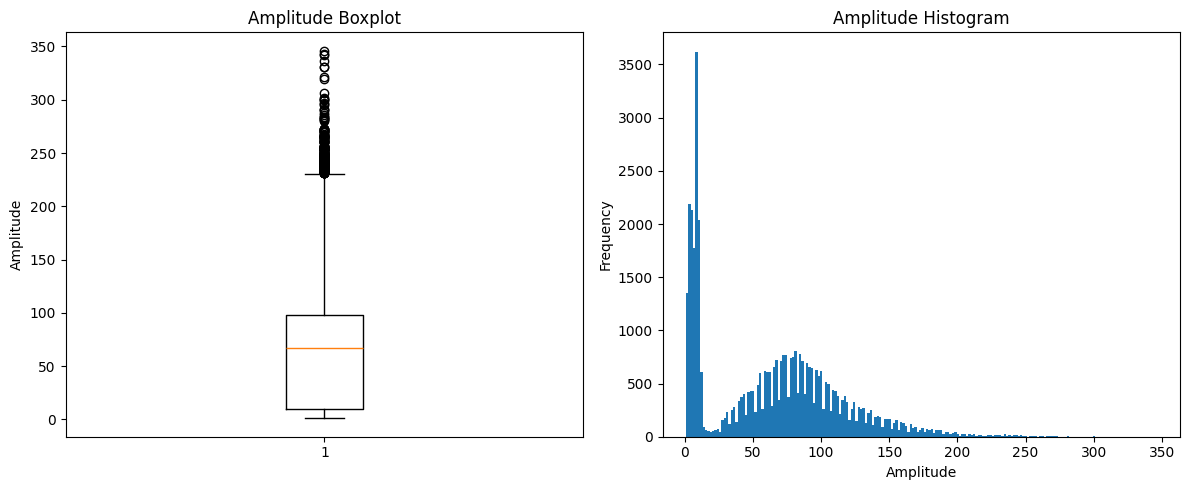

In [59]:
# Plot the distribution of 'amplitudes' in the dataframe
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

#First plot: Boxplot of 'amplitude'
axes[0].boxplot(df['amplitude'])
axes[0].set_title('Amplitude Boxplot')
axes[0].set_ylabel('Amplitude')

# Plot histogram of the column 'amplitude' in the dataframe
axes[1].hist(df['amplitude'], bins=200)
axes[1].set_title('Amplitude Histogram')
axes[1].set_xlabel('Amplitude')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [10]:
# Save df to csv on Desktop and load df as a pandas dataframe
# df.to_csv(r'C:\Users\Lab admin\Desktop\detections.csv')
# df_compare = pd.read_csv(r'C:\Users\Lab admin\Desktop\detections.csv')

In [11]:
# df_compare = pd.read_pickle(r'C:\Users\Lab admin\Desktop\u-Track3D\testTrackability/OS_41_5-10min-01_processed-cropped_channel3_analysis/detection_results/channel_1_detections.pkl')

In [25]:
# Code to export overlaid detections on MIPs of the zarr file

def create_mip_with_spots_napari(zarr_path, spots_df, pixel_size_um=0.1, 
                                  time_point=0, channel=0):
    """
    Create MIP with spot overlays using Napari
    
    Parameters:
    -----------
    zarr_path : str
        Path to zarr file
    spots_df : pd.DataFrame
        DataFrame with columns ['x', 'y', 'z', 't'] or ['x', 'y', 'z']
    pixel_size_um : float
        Pixel size in micrometers for scale bar
    time_point : int
        Time point to display
    channel : int
        Channel to display (if multichannel)
    """
    
    # Load zarr data
    data = zarr.open(zarr_path, mode='r')
    
    # Extract the relevant timepoint and channel
    # Adjust indexing based on your data dimensions (TCZYX, TZYX, etc.)
    if len(data.shape) == 5:  # TCZYX
        volume = data[time_point, channel, :, :, :]
    elif len(data.shape) == 4:  # TZYX or CZYX
        if 'frame' in spots_df.columns:
            volume = data[time_point, :, :, :]
        else:
            volume = data[channel, :, :, :]
    else:  # ZYX
        volume = data[:, :, :]
    
    # Create MIP
    mip = np.max(volume, axis=0)
    
    # Filter spots for current timepoint if time column exists
    if 'frame' in spots_df.columns:
        current_spots = spots_df[spots_df['frame'] == time_point]
    else:
        current_spots = spots_df
    
    # Create Napari viewer
    viewer = napari.Viewer()
    
    # Add MIP as image layer
    viewer.add_image(mip, name='MIP', colormap='gray')
    
    # Add spots as points layer
    spot_coords = current_spots[['mu_y', 'mu_x']].values  # Note: napari uses y,x order
    viewer.add_points(
        spot_coords,
        size=2,
        edge_color='red',
        face_color='transparent',
        # edge_width=2,
        name='Detected Spots'
    )
    
    # Set scale bar
    viewer.scale_bar.visible = True
    viewer.scale_bar.unit = "um"
    viewer.dims.ndisplay = 2
    
    return viewer

In [13]:
# create_mip_with_spots_napari(
#     zarr_full_path, 
#     df,  # Use the same time point as before
#     pixel_size_um=0.1450, 
#     time_point=119, 
#     channel=2  # Adjust based on your data
# )

In [26]:
def create_publication_figure(zarr_path, spots_df, pixel_size_um=0.1,
                             time_point=0, channel=0, 
                             zoom_coords=None, zoom_size=100,
                             save_path='figure.png', dpi=300):
    """
    Create publication-quality figure with full view and zoomed inset
    
    Parameters:
    -----------
    zarr_path : str
        Path to zarr file
    spots_df : pd.DataFrame
        DataFrame with columns ['x', 'y', 'z', 't'] or ['x', 'y', 'z']
    pixel_size_um : float
        Pixel size in micrometers
    time_point : int
        Time point to display
    channel : int
        Channel to display
    zoom_coords : tuple
        (x, y) coordinates for zoom center
    zoom_size : int
        Size of zoom region in pixels
    save_path : str
        Output file path
    dpi : int
        Resolution for saved figure
    """
    
    # Load data and create MIP
    data = zarr.open(zarr_path, mode='r')
    
    # Extract volume (adjust based on your dimensions)
    if len(data.shape) == 5:  # TCZYX
        volume = data[time_point, channel, :, :, :]
    elif len(data.shape) == 4:  # TZYX
        volume = data[time_point, :, :, :]
    else:  # ZYX
        volume = data[:, :, :]
    
    mip = np.max(volume, axis=0)
    
    # Enhance contrast
    mip_enhanced = exposure.equalize_adapthist(
        mip / mip.max(), clip_limit=0.03
    )
    
    # Filter spots
    if 'frame' in spots_df.columns:
        current_spots = spots_df[spots_df['frame'] == time_point]
    else:
        current_spots = spots_df
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Full view
    ax1.imshow(mip, cmap='gray')
    # ax1.scatter(current_spots['mu_x'], current_spots['mu_y'], 
    #             s=50, facecolors='none', edgecolors='red', linewidths=1.5)
    ax1.axis('off')
    ax1.set_title('Full View', fontsize=14)
    
    # Add scale bar to full view
    scalebar1 = ScaleBar(pixel_size_um, units='um', location='lower right',
                        color='white', box_color='black', box_alpha=0.5)
    ax1.add_artist(scalebar1)
    
    # Zoomed view
    if zoom_coords is None:
        # Auto-select zoom region with highest spot density
        if len(current_spots) > 0:
            zoom_x = int(current_spots['mu_x'].mean())
            zoom_y = int(current_spots['mu_y'].mean())
        else:
            zoom_x, zoom_y = mip.shape[1]//2, mip.shape[0]//2
    else:
        zoom_x, zoom_y = zoom_coords
    
    # Extract zoom region
    x_start = max(0, zoom_x - zoom_size//2)
    x_end = min(mip.shape[1], zoom_x + zoom_size//2)
    y_start = max(0, zoom_y - zoom_size//2)
    y_end = min(mip.shape[0], zoom_y + zoom_size//2)
    
    zoom_region = mip[y_start:y_end, x_start:x_end]
    
    ax2.imshow(zoom_region, cmap='gray')
    
    # Plot spots in zoom region
    zoom_spots = current_spots[
        (current_spots['mu_x'] >= x_start) & (current_spots['mu_x'] < x_end) &
        (current_spots['mu_y'] >= y_start) & (current_spots['mu_y'] < y_end)
    ]
    
    if len(zoom_spots) > 0:
        ax2.scatter(zoom_spots['mu_x'] - x_start, zoom_spots['mu_y'] - y_start,
                    s=100, facecolors='none', edgecolors='red', linewidths=2)
    
    ax2.axis('off')
    ax2.set_title('Zoomed View', fontsize=14)
    
    # Add scale bar to zoom view
    scalebar2 = ScaleBar(pixel_size_um, units='um', location='lower right',
                        color='white', box_color='black', box_alpha=0.5)
    ax2.add_artist(scalebar2)
    
    # Add zoom indicator on full view
    rect = mpatches.Rectangle((x_start, y_start), 
                             x_end - x_start, y_end - y_start,
                             linewidth=2, edgecolor='yellow', 
                             facecolor='none', linestyle='--')
    ax1.add_patch(rect)
    
    plt.tight_layout()
    # plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    # plt.show()
    plt.close(fig)  # Close the figure to free memory
    return fig

/var/folders/0s/t8g59tpd7yv290krn_d3fn1h0000gp/T/ipykernel_58693/1150939688.py:88: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.imshow(zoom_region, cmap='gray')


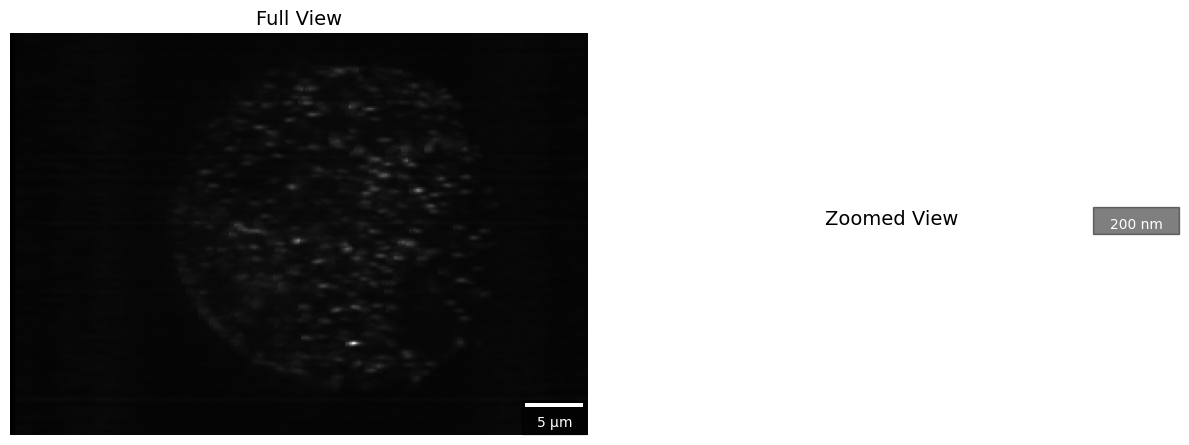

In [15]:
create_publication_figure(
    zarr_full_path, 
    df,  # Use the same time point as before
    pixel_size_um=0.145, 
    time_point=4, 
    channel=2,  # Adjust based on your data
    zoom_coords=(100, 1000),  # Example zoom center
    zoom_size=10,  # Example zoom size
    save_path='publication_figure.png',  # Save path for the figure
    dpi=300  # DPI for publication quality
)